# 🌳 Árbol de Decisión CART — Clasificación Binaria de Películas

Construcción, entrenamiento y evaluación de un modelo de
**Árbol de Decisión CART** para predecir
si una película será considerada exitosa (`pelicula_exitosa = 1`).

| | |
|---|---|
| **Variable objetivo (Y)** | `pelicula_exitosa` (1 = Exitosa, 0 = No exitosa) |
| **Variables predictoras (X)** | `anio`, `imdb_rating`, `genero` |
| **Modelo** | `DecisionTreeClassifier` — criterio Gini (CART, scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 60/40 · 70/30 |

> Dataset de películas almacenado en PostgreSQL.

> A diferencia de la Regresión Logística,
el árbol CART no requiere escalado de variables y
mide la importancia de cada predictor mediante
la reducción de impureza Gini.

In [3]:
# ─────────────────────────────────────────────────────────────
# CELDA 0 — Configuración de rutas
# ─────────────────────────────────────────────────────────────

import os

CARPETA_GRAFICAS = "../data/graficas/arbol_de_decision_para_clasificacion"

os.makedirs(CARPETA_GRAFICAS, exist_ok=True)

print("✅ Carpeta de gráficas verificada")
print(f"📁 Ruta: {CARPETA_GRAFICAS}")

✅ Carpeta de gráficas verificada
📁 Ruta: ../data/graficas/arbol_de_decision_para_clasificacion


In [4]:
# ─────────────────────────────────────────────────────────────
# CELDA 1 — Importaciones
# ─────────────────────────────────────────────────────────────

import sys
import os

sys.path.append("../Etl-Proyecto")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")

print("✅ Librerías importadas correctamente :)")

✅ Librerías importadas correctamente :)


In [5]:
# ─────────────────────────────────────────────────────────────
# CELDA 2 — Conexión PostgreSQL y carga de datos
# ─────────────────────────────────────────────────────────────

from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import pandas as pd
import os

# Cargar variables del archivo .env
load_dotenv()

# Obtener DATABASE_URL desde .env
DATABASE_URL = os.getenv("DATABASE_URL")

print("✅ Variable de entorno cargada")

# Crear conexión
engine = create_engine(DATABASE_URL)

SQL_QUERY = """
SELECT *
FROM registro_peliculas
"""

with engine.connect() as conn:
    df_peliculas = pd.read_sql(text(SQL_QUERY), conn)

print("✅ Datos cargados correctamente")
print(df_peliculas.head())

✅ Variable de entorno cargada
✅ Datos cargados correctamente
   id  pelicula_id  anio                      genero           director  \
0   1            1  2010   Action, Adventure, Sci-Fi  Christopher Nolan   
1   2            2  2014    Adventure, Drama, Sci-Fi  Christopher Nolan   
2   3            3  2008        Action, Crime, Drama  Christopher Nolan   
3   4            4  2019             Drama, Thriller       Bong Joon Ho   
4   5            5  2009  Action, Adventure, Fantasy      James Cameron   

                                             actores  imdb_rating  duracion  \
0  Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...          8.8     148.0   
1  Matthew McConaughey, Anne Hathaway, Jessica Ch...          8.7     169.0   
2        Christian Bale, Heath Ledger, Aaron Eckhart          9.1     152.0   
3          Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong          8.5     132.0   
4     Sam Worthington, Zoe Saldaña, Sigourney Weaver          7.9     162.0   

   recaudacio

In [6]:
# DIAGNÓSTICO — correr antes del preprocesamiento
print("Columnas en df_peliculas:")
print(df_peliculas.columns.tolist())
print(f"\nShape: {df_peliculas.shape}")

Columnas en df_peliculas:
['id', 'pelicula_id', 'anio', 'genero', 'director', 'actores', 'imdb_rating', 'duracion', 'recaudacion', 'idioma', 'pais', 'fecha_extraccion']

Shape: (535, 12)


In [7]:
# ─────────────────────────────────────────────────────────────
# CELDA 3 — Construcción del target + Preprocesamiento
# ─────────────────────────────────────────────────────────────

df = df_peliculas.copy()

# ── Construir variable objetivo ───────────────────────────────
df["pelicula_exitosa"] = (
    (df["imdb_rating"] >= 7.0) &
    (df["recaudacion"] > 0)
).astype(int)

print("📌 Balance de clases construido:")
print(df["pelicula_exitosa"].value_counts())
print(f"   Proporción exitosas: {df['pelicula_exitosa'].mean():.1%}")

y = df["pelicula_exitosa"]

# ── Eliminar columnas con fuga o sin valor predictivo ─────────
drop_cols = [
    "pelicula_exitosa", "id", "pelicula_id",
    "fecha_extraccion", "imdb_rating", "recaudacion"
]
df = df.drop(columns=drop_cols, errors="ignore")

# ── Género: solo el primero antes de la coma ──────────────────
df["genero"] = df["genero"].str.split(",").str[0].str.strip()

# ── País: solo el primero antes de la coma ────────────────────
df["pais"] = df["pais"].str.split(",").str[0].str.strip()

# ── Agrupar directores poco frecuentes ───────────────────────
TOP_N = 15
top_dir = df["director"].value_counts().head(TOP_N).index
df["director"] = df["director"].apply(lambda x: x if x in top_dir else "Otro")

# ── Actores → cantidad ────────────────────────────────────────
df["cantidad_actores"] = df["actores"].apply(lambda x: len(str(x).split(",")))
df.drop(columns=["actores"], inplace=True)

# ── Idioma → binario (English vs Otro) ───────────────────────
df["es_ingles"] = (df["idioma"].str.contains("English", na=False)).astype(int)
df.drop(columns=["idioma"], inplace=True)

# ── Dummies sobre categorías ya reducidas ────────────────────
df = pd.get_dummies(df, columns=["genero", "director", "pais"], drop_first=True)

X = df.drop(columns=["pelicula_exitosa"], errors="ignore")

# Convertir datetime si queda alguna
for col in X.select_dtypes(include=["datetime64[ns]"]).columns:
    X[col] = X[col].astype("int64") // 10**9

print(f"\n✅ Preprocesamiento completado")
print(f"   Shape X : {X.shape}")
print(f"   Shape y : {y.shape}")
print(f"\n📌 Primeras 10 features:")
print(list(X.columns[:10]))
print("\n📌 Tipos de datos:")
print(X.dtypes.value_counts())

📌 Balance de clases construido:
pelicula_exitosa
1    347
0    188
Name: count, dtype: int64
   Proporción exitosas: 64.9%

✅ Preprocesamiento completado
   Shape X : (535, 64)
   Shape y : (535,)

📌 Primeras 10 features:
['anio', 'duracion', 'cantidad_actores', 'es_ingles', 'genero_Adult', 'genero_Adventure', 'genero_Animation', 'genero_Biography', 'genero_Comedy', 'genero_Crime']

📌 Tipos de datos:
bool       60
int64       3
float64     1
Name: count, dtype: int64


In [8]:
# ─────────────────────────────────────────────────────────────
# CELDA 4 — Función entrenar/evaluar
# ─────────────────────────────────────────────────────────────

def entrenar_evaluar(X, y, test_size, nombre):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=15,
    min_samples_leaf=5,
    random_state=42
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        "nombre": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "fpr": fpr,
        "tpr": tpr,
        "y_test": y_test,
        "y_pred": y_pred,
        "modelo": modelo
    }

print("✅ Función creada correctamente")

✅ Función creada correctamente


In [9]:
# ─────────────────────────────────────────────────────────────
# CELDA 5 — Ejecutar splits
# ─────────────────────────────────────────────────────────────

# Convertir columnas datetime a número
for col in X.select_dtypes(include=['datetime64[ns]']).columns:
    X[col] = X[col].astype('int64') // 10**9

# Ejecutar modelos con distintos splits
resultados = [
    entrenar_evaluar(X, y, 0.20, "Split 80/20"),
    entrenar_evaluar(X, y, 0.40, "Split 60/40"),
    entrenar_evaluar(X, y, 0.30, "Split 70/30")
]

# Mostrar resultados
for r in resultados:
    print("\n" + "="*50)
    print(f"RESULTADOS {r['nombre']}")
    print("="*50)

    print(f"Accuracy : {r['accuracy']:.4f}")
    print(f"Precision: {r['precision']:.4f}")
    print(f"Recall   : {r['recall']:.4f}")
    print(f"F1 Score : {r['f1']:.4f}")
    print(f"ROC AUC  : {r['roc_auc']:.4f}")


RESULTADOS Split 80/20
Accuracy : 0.7383
Precision: 0.8060
Recall   : 0.7826
F1 Score : 0.7941
ROC AUC  : 0.7687

RESULTADOS Split 60/40
Accuracy : 0.7430
Precision: 0.8000
Recall   : 0.8058
F1 Score : 0.8029
ROC AUC  : 0.7630

RESULTADOS Split 70/30
Accuracy : 0.7578
Precision: 0.7928
Recall   : 0.8462
F1 Score : 0.8186
ROC AUC  : 0.7634


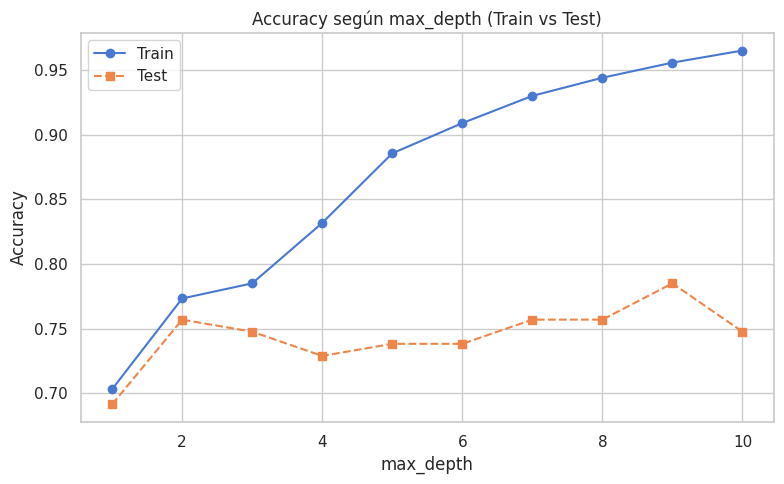

✅ Gráfica max_depth guardada
   Mejor test accuracy: 0.7850 en max_depth=9


In [10]:
# ─────────────────────────────────────────────────────────────
# CELDA 6 — Búsqueda max_depth
# ─────────────────────────────────────────────────────────────

profundidades = range(1, 11)
scores_train = []
scores_test  = []

for d in profundidades:

    modelo_d = DecisionTreeClassifier(max_depth=d, random_state=42)

    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    modelo_d.fit(X_train_d, y_train_d)

    scores_train.append(modelo_d.score(X_train_d, y_train_d))
    scores_test.append(modelo_d.score(X_test_d, y_test_d))

plt.figure(figsize=(8, 5))
plt.plot(profundidades, scores_train, marker="o", label="Train")
plt.plot(profundidades, scores_test,  marker="s", label="Test",  linestyle="--")
plt.title("Accuracy según max_depth (Train vs Test)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CARPETA_GRAFICAS}/max_depth.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfica max_depth guardada")
print(f"   Mejor test accuracy: {max(scores_test):.4f} en max_depth={scores_test.index(max(scores_test))+1}")

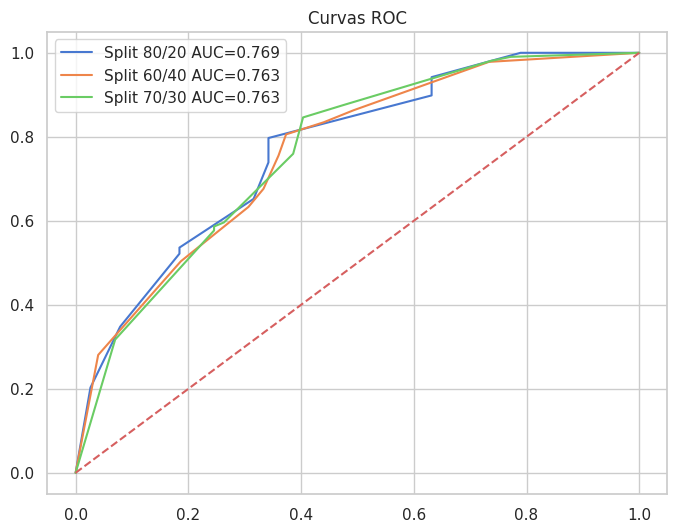

✅ Curvas ROC guardadas


In [11]:
# ─────────────────────────────────────────────────────────────
# CELDA 7 — Curvas ROC
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(8,6))

for r in resultados:

    plt.plot(
        r["fpr"],
        r["tpr"],
        label=f"{r['nombre']} AUC={r['roc_auc']:.3f}"
    )

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("Curvas ROC")

plt.savefig(
    f"{CARPETA_GRAFICAS}/roc.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Curvas ROC guardadas")

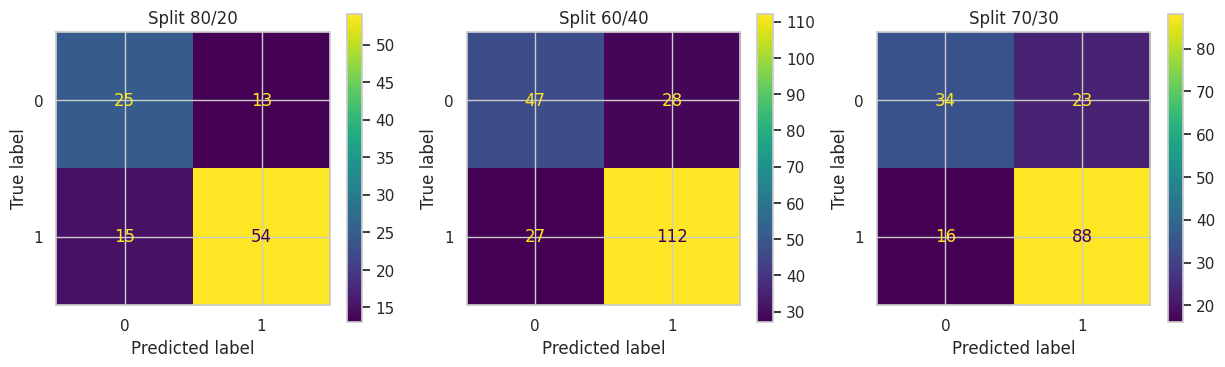

✅ Matrices de confusión guardadas


In [12]:
# ─────────────────────────────────────────────────────────────
# CELDA 8 — Matrices de confusión
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1,3, figsize=(15,4))

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(r["y_test"], r["y_pred"])

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(ax=ax)

    ax.set_title(r["nombre"])

plt.savefig(
    f"{CARPETA_GRAFICAS}/confusion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Matrices de confusión guardadas")

In [13]:
# ─────────────────────────────────────────────────────────────
# CELDA 9 — Métricas comparativas
# ─────────────────────────────────────────────────────────────

metricas = pd.DataFrame([
    {
        "Split": r["nombre"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC_AUC": r["roc_auc"]
    }
    for r in resultados
])

display(metricas)

print("✅ Tabla de métricas generada")

,Split,Accuracy,Precision,Recall,F1,ROC_AUC
0,Split 80/20,0.738318,0.805970,0.782609,0.794118,0.768688
1,Split 60/40,0.742991,0.800000,0.805755,0.802867,0.763022
2,Split 70/30,0.757764,0.792793,0.846154,0.818605,0.763411


✅ Tabla de métricas generada


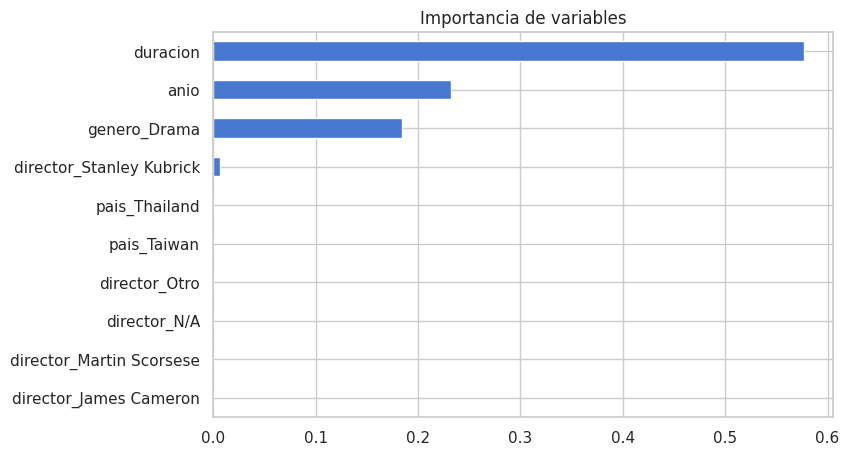

✅ Feature importance generada


In [14]:
# ─────────────────────────────────────────────────────────────
# CELDA 10 — Feature importance
# ─────────────────────────────────────────────────────────────

modelo = resultados[0]["modelo"]

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
)

importancias = importancias.sort_values()

plt.figure(figsize=(8,5))

importancias.tail(10).plot(kind="barh")

plt.title("Importancia de variables")

plt.savefig(
    f"{CARPETA_GRAFICAS}/feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Feature importance generada")

In [15]:
# ─────────────────────────────────────────────────────────────
# CELDA 11 — Tabla final
# ─────────────────────────────────────────────────────────────

resumen = metricas.copy()

display(resumen)

print("✅ Resumen final generado")

print("------")


,Split,Accuracy,Precision,Recall,F1,ROC_AUC
0,Split 80/20,0.738318,0.805970,0.782609,0.794118,0.768688
1,Split 60/40,0.742991,0.800000,0.805755,0.802867,0.763022
2,Split 70/30,0.757764,0.792793,0.846154,0.818605,0.763411


✅ Resumen final generado
------


In [16]:
# ─────────────────────────────────────────────────────────────
# CELDA 12 — Interpretación de resultados
# ─────────────────────────────────────────────────────────────

mejor = metricas.sort_values("F1", ascending=False).iloc[0]

print("=" * 55)
print("  INTERPRETACIÓN DEL MODELO")
print("=" * 55)
print(f"  Mejor split        : {mejor['Split']}")
print(f"  Accuracy           : {mejor['Accuracy']:.4f}")
print(f"  F1 Score           : {mejor['F1']:.4f}")
print(f"  ROC AUC            : {mejor['ROC_AUC']:.4f}")
print("=" * 55)

if mejor["Accuracy"] >= 0.99:
    print("⚠️  ADVERTENCIA: Accuracy >= 0.99 puede indicar")
    print("   fuga de información. Revisar features usadas.")
elif mejor["Accuracy"] >= 0.80:
    print("✅ Rendimiento bueno. Modelo generaliza bien.")
elif mejor["Accuracy"] >= 0.65:
    print("⚠️  Rendimiento aceptable. Considerar más features")
    print("   o ajustar hiperparámetros.")
else:
    print("❌ Rendimiento bajo. Revisar calidad de los datos.")

print(f"\n📌 Features utilizadas : {X.shape[1]}")
print(f"📌 Muestras totales    : {len(y)}")
print(f"📌 Balance clases      : {y.value_counts().to_dict()}")

  INTERPRETACIÓN DEL MODELO
  Mejor split        : Split 70/30
  Accuracy           : 0.7578
  F1 Score           : 0.8186
  ROC AUC            : 0.7634
⚠️  Rendimiento aceptable. Considerar más features
   o ajustar hiperparámetros.

📌 Features utilizadas : 64
📌 Muestras totales    : 535
📌 Balance clases      : {1: 347, 0: 188}
